In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Stroke_detetection_dataset.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Female,46.0,0,0,Yes,Private,Rural,100.15,50.3,smokes,0
1,2,Male,80.0,0,0,Yes,Self-employed,Rural,196.08,31.0,formerly smoked,0
2,3,Female,1.16,0,0,No,children,Urban,97.28,17.8,Unknown,0
3,4,Female,61.0,1,0,Yes,Private,Rural,170.05,60.2,smokes,0
4,5,Male,43.0,0,0,Yes,Govt_job,Rural,88.00,30.6,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Female,69.0,0,0,Yes,Self-employed,Urban,113.10,22.7,never smoked,0
49996,49997,Male,58.0,1,0,No,Private,Urban,55.78,27.5,smokes,0
49997,49998,Female,51.0,0,0,Yes,Self-employed,Urban,111.15,34.1,smokes,0
49998,49999,Male,71.0,0,0,Yes,Govt_job,Urban,56.12,24.7,Unknown,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 50000 non-null  int64  
 1   gender             50000 non-null  str    
 2   age                50000 non-null  str    
 3   hypertension       50000 non-null  int64  
 4   heart_disease      50000 non-null  int64  
 5   ever_married       50000 non-null  str    
 6   work_type          50000 non-null  str    
 7   Residence_type     50000 non-null  str    
 8   avg_glucose_level  49450 non-null  float64
 9   bmi                48098 non-null  str    
 10  smoking_status     50000 non-null  str    
 11  stroke             50000 non-null  int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 6.4 MB


In [4]:
#check the datatypes
print("DATATYPE OF EACH COLUMN (df.dtypes):")
print(df.dtypes)

DATATYPE OF EACH COLUMN (df.dtypes):
id                     int64
gender                   str
age                      str
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                      str
smoking_status           str
stroke                 int64
dtype: object


In [5]:
df.describe()

,id,hypertension,heart_disease,avg_glucose_level,stroke
count,50000.000000,50000.000000,50000.000000,49450.000000,50000.000000
mean,25000.500000,0.151100,0.045200,108.887037,0.048340
std,14433.901067,0.748519,0.234858,69.470553,0.214486
min,1.000000,0.000000,-1.000000,-25.000000,0.000000
25%,12500.750000,0.000000,0.000000,77.120000,0.000000
50%,25000.500000,0.000000,0.000000,91.850000,0.000000
75%,37500.250000,0.000000,0.000000,114.160000,0.000000
max,50000.000000,9.000000,1.000000,850.000000,1.000000


In [6]:
df.isnull().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level     550
bmi                  1902
smoking_status          0
stroke                  0
dtype: int64

In [7]:
#data cleaning

In [8]:
# 1. Drop useless ID column
df = df.drop(columns=['id'],errors='ignore')

# 2. Handle missing BMI values - convert to numeric first
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce') # turns text to NaN
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# 3. Fix gender column: replace 'Other' with mode
df['gender'] = df['gender'].replace('Other', df['gender'].mode()[0])

# 4. Fix smoking status: replace 'Unknown' with mode of known values
mode_smoking = df.loc[df['smoking_status']!= 'Unknown', 'smoking_status'].mode()[0] # ✅ Fixed typo + added [0]
df['smoking_status'] = df['smoking_status'].replace('Unknown', mode_smoking)

# 5. Remove duplicates
df = df.drop_duplicates()

print("Data Cleaning Completed!")
df.info()

Data Cleaning Completed!
<class 'pandas.DataFrame'>
Index: 8355 entries, 0 to 49979
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             8355 non-null   str    
 1   age                8355 non-null   str    
 2   hypertension       8355 non-null   int64  
 3   heart_disease      8355 non-null   int64  
 4   ever_married       8355 non-null   str    
 5   work_type          8355 non-null   str    
 6   Residence_type     8355 non-null   str    
 7   avg_glucose_level  7833 non-null   float64
 8   bmi                8355 non-null   float64
 9   smoking_status     8355 non-null   str    
 10  stroke             8355 non-null   int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 1.1 MB


In [9]:
df.describe()

,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,8355.000000,8355.000000,7833.000000,8355.000000,8355.00000
mean,0.407780,0.015799,125.801506,35.650521,0.05003
std,1.658175,0.289864,138.313502,49.349682,0.21802
min,0.000000,-1.000000,-25.000000,-1.000000,0.00000
25%,0.000000,0.000000,76.430000,23.900000,0.00000
50%,0.000000,0.000000,91.850000,28.000000,0.00000
75%,0.000000,0.000000,116.500000,32.700000,0.00000
max,9.000000,1.000000,850.000000,350.000000,1.00000


In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(" outliers before cleaning:")
for col in numeric_cols:
    Q1 =df[col].quantile(0.25)
    Q3 =df[col].quantile(0.75)
    Q3 =  df[col].quantile (0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 2.5 * IQR
    upper_bound = Q3 + 4.6* IQR

outliers = df[(df[col] < lower_bound) | (df [col] > upper_bound)]

print(f"{col}: {len (outliers)} outliers")


 outliers before cleaning:
stroke: 418 outliers


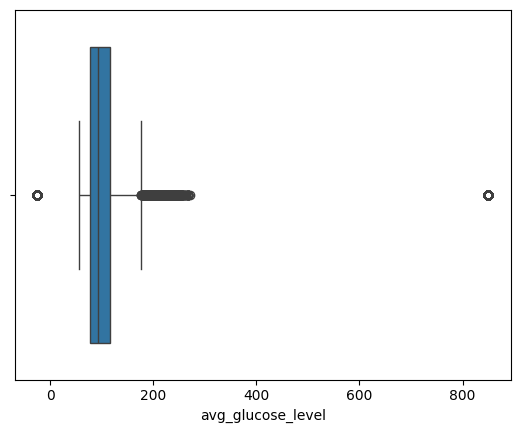

In [11]:
sns.boxplot(data=df,x='avg_glucose_level')
plt.show()

In [12]:
X= np.quantile(df['avg_glucose_level'].dropna(),(0.25, 0.75))
Q3 =X [1]
Q1 =X [0]
print('Q1:',Q1)
print('Q3:',Q3)

Q1: 76.43
Q3: 116.5


In [13]:
IQR = Q3 -  Q1
uw = Q3 + 1.5*IQR
lw = Q1 - 1.5*IQR
print('Upper Bound: ',  uw)
print('Lower Bound: ', lw)


Upper Bound:  176.605
Lower Bound:  16.325000000000017


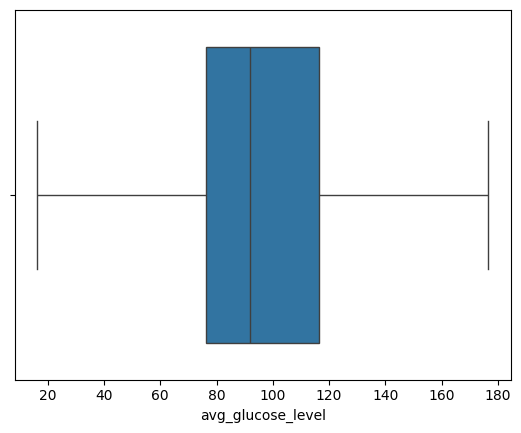

In [14]:
df['avg_glucose_level'] = np.where(df['avg_glucose_level'] > uw,uw,df['avg_glucose_level'])
df['avg_glucose_level'] = np.where(df['avg_glucose_level'] < lw,lw,df['avg_glucose_level'])
data = sns.boxplot(x = 'avg_glucose_level', data = df)
plt.show()

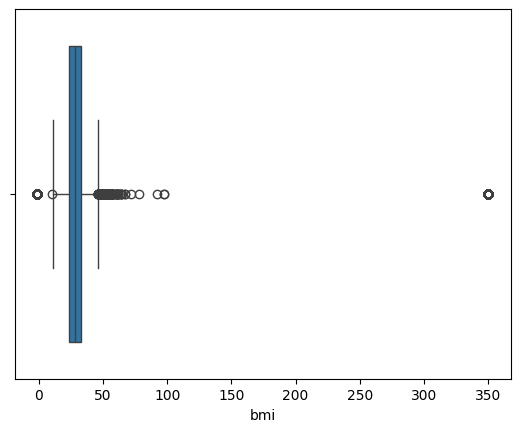

In [15]:
sns.boxplot(data=df,x='bmi')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['age'],bins=30,kde=True)
plt.title("age profile")
plt.show()


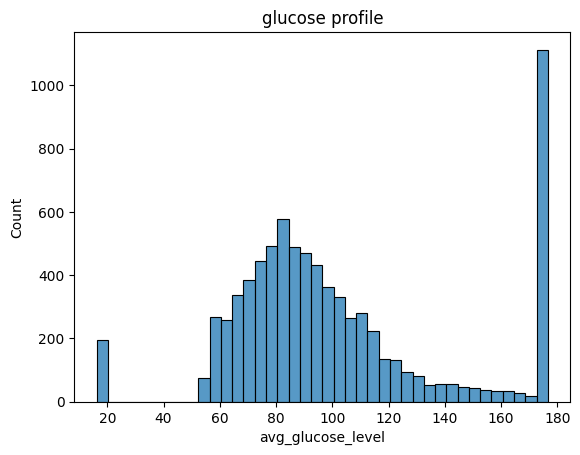

In [16]:
sns.histplot(x='avg_glucose_level',data=df)
plt.title("glucose profile")
plt.show()

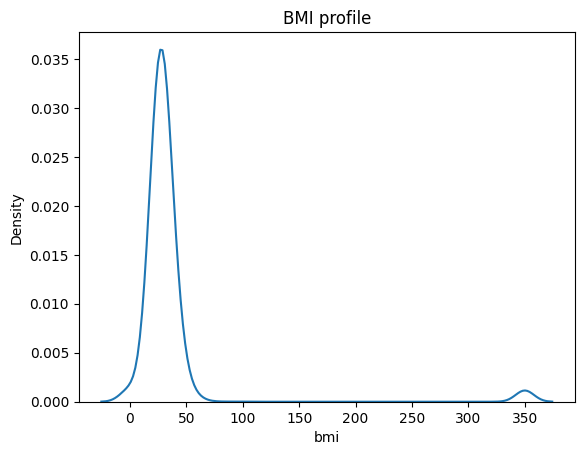

In [17]:
sns.kdeplot(x='bmi',data=df)
plt.title("BMI profile")
plt.show()

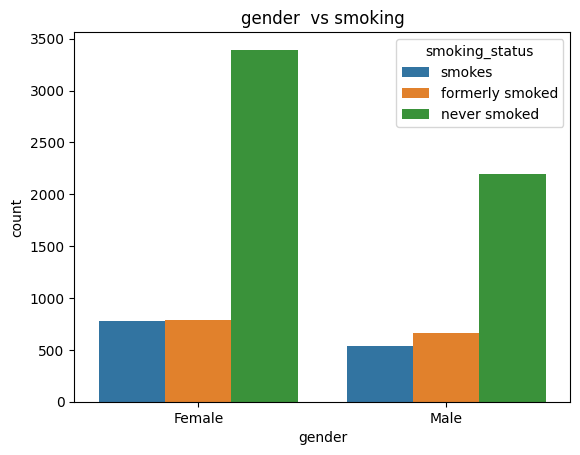

In [18]:
sns.countplot(data=df,x='gender',hue='smoking_status')
plt.title("gender  vs smoking")
plt.xlabel("gender")
plt.ylabel("count")
plt.show()

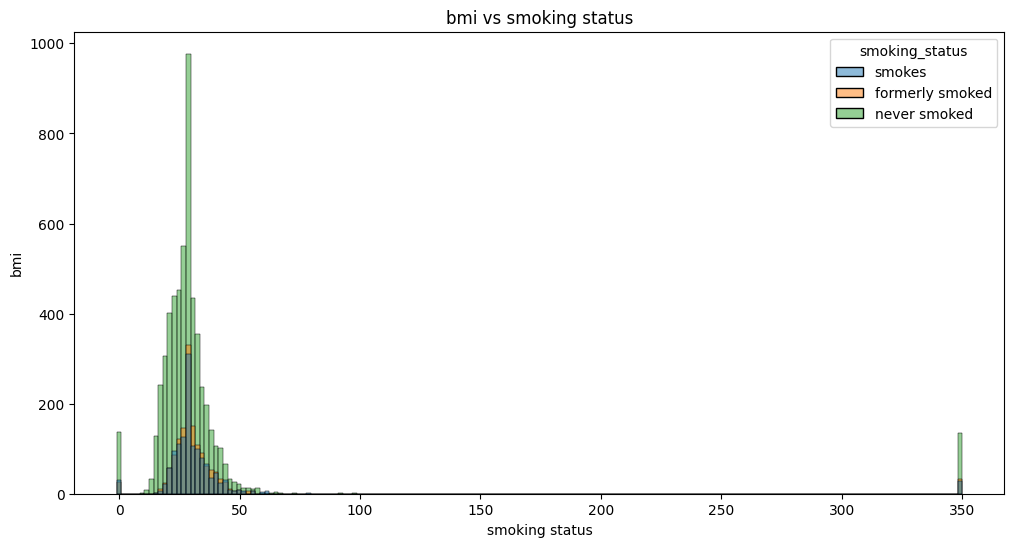

In [19]:
plt.figure(figsize=(12,6))
sns.histplot(data=df,x='bmi',
hue='smoking_status')
plt.title("bmi vs smoking status")
plt.xlabel("smoking status")
plt.ylabel("bmi")
plt.show()

In [20]:
# STROKE CLASSIFICATION


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [22]:
#copy the cleaned data
data = df.copy()

In [23]:
# Encode categorical columns
cat_cols = data.select_dtypes(include=['object', 'string']).columns
le = LabelEncoder()

for col in cat_cols:
  data[col] = le.fit_transform(data[col])

In [24]:
# Features and target
X = data.drop("stroke", axis=1)
y = data["stroke"]

    

In [25]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [27]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [28]:
# Predict
y_pred = model.predict(X_test)



In [29]:
# Accuracy
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91      1587
           1       0.19      0.68      0.29        84

    accuracy                           0.84      1671
   macro avg       0.58      0.76      0.60      1671
weighted avg       0.94      0.84      0.88      1671



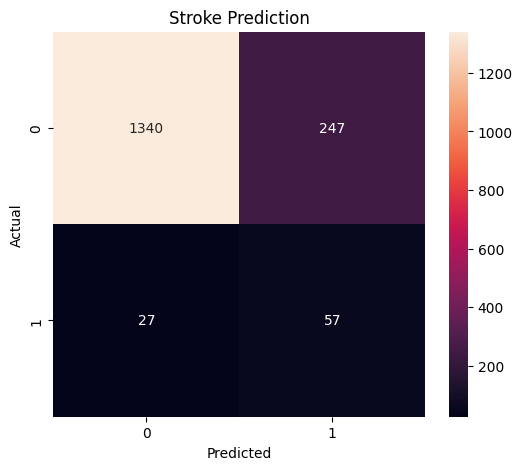

In [30]:
# Report
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stroke Prediction")
plt.show()


In [31]:
import pandas as pd

# Enter new patient data
new_data = pd.DataFrame({
    'gender': [1],
    'age': [45],
    'hypertension': [0],
    'heart_disease': [0],
    'ever_married': [1],
    'work_type': [2],
    'Residence_type': [1],
    'avg_glucose_level': [120],
    'bmi': [26],
    'smoking_status': [1]
})

In [32]:
# Predict
prediction = model.predict(new_data)

print("Prediction:", prediction)

Prediction: [0]


In [33]:
new_data = pd.DataFrame({
    'gender':[1],
    'age':[85],
    'hypertension':[1],
    'heart_disease':[1],
    'ever_married':[1],
    'work_type':[2],
    'Residence_type':[1],
    'avg_glucose_level':[2800],
    'bmi':[50],
    'smoking_status':[2]
})


In [34]:
y_pred = model.predict(new_data)

print("Prediction:", y_pred)

Prediction: [1]


In [35]:
print(model.predict_proba(new_data))

[[0.47182279 0.52817721]]


In [36]:
print(df['stroke'].value_counts())

stroke
0    7937
1     418
Name: count, dtype: int64


## Saving the Model

In [37]:
import joblib as jb

In [38]:
jb.dump(model, "stroke.pkl")

['stroke.pkl']